<a href="https://colab.research.google.com/github/thisishasan/speech_processing/blob/main/06_training_loss_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3638/3694742040.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


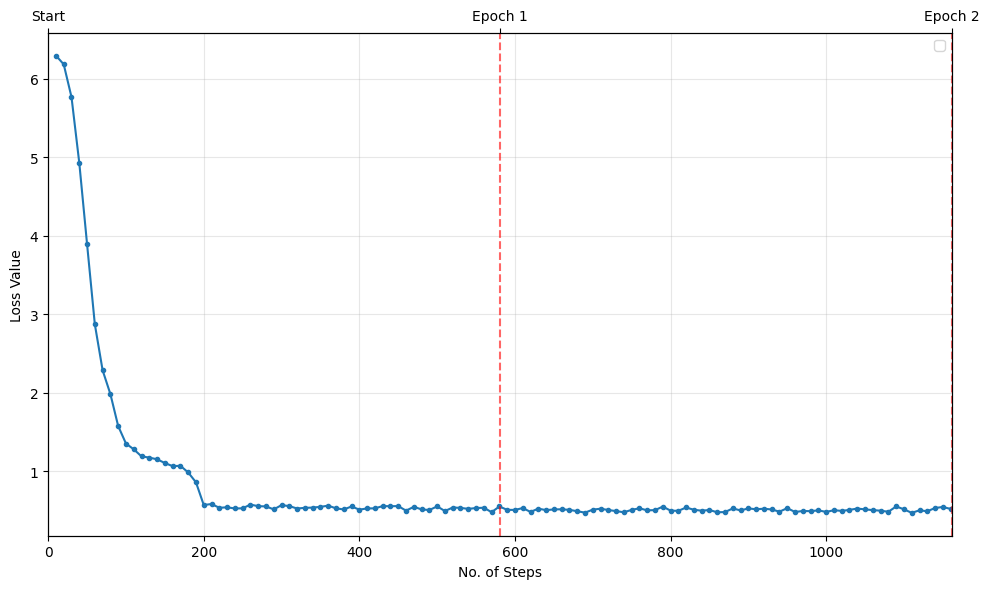

In [7]:
import json
import glob
import os
import math
import matplotlib.pyplot as plt

OUTPUT_DIR = (
    "/content/drive/MyDrive/01_speech_processing/"
    "sp_exam_project/dataset/hf_llava_checkpoints"
)

checkpoint_files = glob.glob(
    os.path.join(OUTPUT_DIR, "checkpoint-*", "trainer_state.json")
)

trainer_state_path = max(
    checkpoint_files,
    key=lambda path: int(
        os.path.basename(os.path.dirname(path)).split("-")[-1]
    )
)

with open(trainer_state_path, "r", encoding="utf-8") as file:
    trainer_state = json.load(file)

log_history = trainer_state["log_history"]

loss_values = [
    item for item in log_history
    if "loss" in item and "step" in item
]

steps = [item["step"] for item in loss_values]
losses = [item["loss"] for item in loss_values]

num_epochs = float(trainer_state.get("num_train_epochs", 1))
max_steps = float(
    trainer_state.get("max_steps", max(steps))
)

steps_per_epoch = max_steps / num_epochs

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    steps,
    losses,
    marker="o",
    markersize=3,
    linewidth=1.5,
)

for epoch in range(1, math.ceil(num_epochs) + 1):
    epoch_step = epoch * steps_per_epoch

    if epoch_step <= max_steps:
        ax.axvline(
            epoch_step,
            color="red",
            linestyle="--",
            alpha=0.6
        )

ax.set_xlim(0, max_steps)
ax.set_xlabel("No. of Steps")
ax.set_ylabel("Loss Value")
ax.grid(True, alpha=0.3)

top_axis = ax.twiny()
top_axis.set_xlim(ax.get_xlim())

epoch_ticks = [
    epoch * steps_per_epoch
    for epoch in range(int(num_epochs) + 1)
]

epoch_labels = [
    "Start" if epoch == 0 else f"Epoch {epoch}"
    for epoch in range(int(num_epochs) + 1)
]

top_axis.set_xticks(epoch_ticks)
top_axis.set_xticklabels(epoch_labels)

ax.legend()
plt.tight_layout()
plt.show()